In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import joblib
import pickle

In [2]:
data = pd.read_csv("fraud_data.csv")

In [3]:
data.columns = data.columns.str.strip().str.lower()

print("\n✅ Columns in dataset:")
for col in data.columns:
    print(f"'{col}'")


✅ Columns in dataset:
'v1'
'v2'
'v3'
'v4'
'v5'
'v6'
'v7'
'v8'
'v9'
'v10'
'v11'
'v12'
'v13'
'v14'
'v15'
'v16'
'v17'
'v18'
'v19'
'v20'
'v21'
'v22'
'v23'
'v24'
'v25'
'v26'
'v27'
'v28'
'amount'
'class'


In [4]:
time_col = None
amount_col = None
target_col = None

for col in data.columns:
    if 'time' in col:
        time_col = col
    if 'amount' in col:
        amount_col = col
    if 'class' in col or 'target' in col:
        target_col = col

print("\nDetected Columns:")
print("Time:", time_col)
print("Amount:", amount_col)
print("Target:", target_col)


Detected Columns:
Time: None
Amount: amount
Target: class


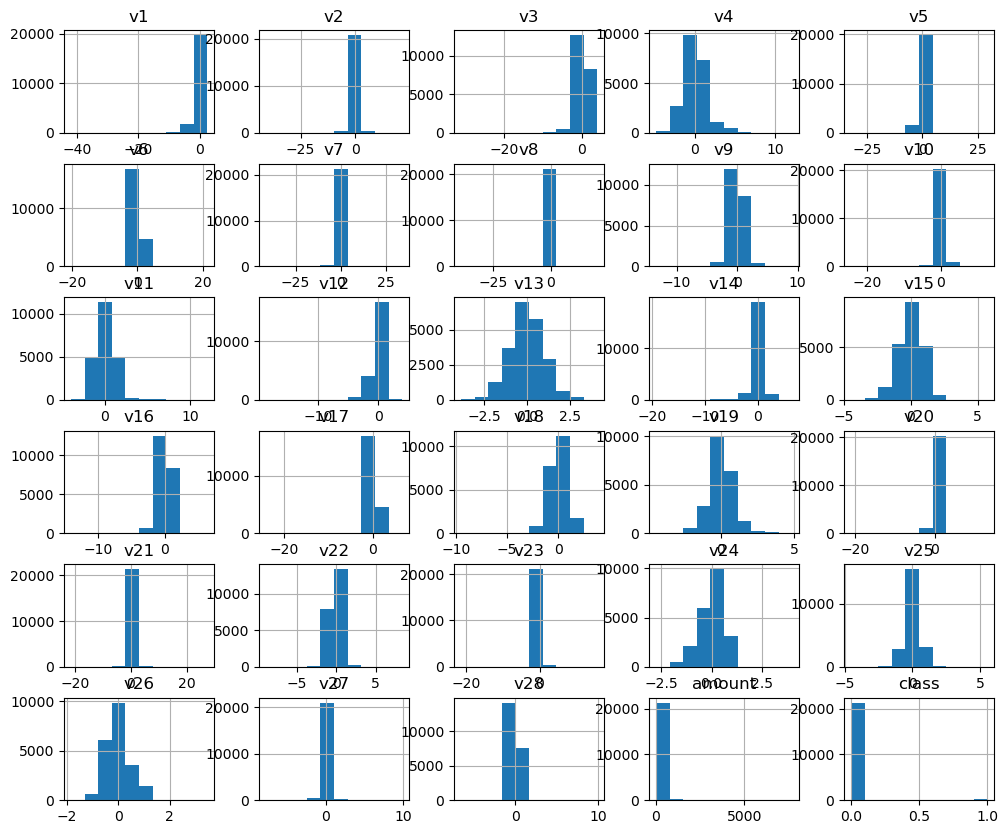

⚠️ Skipping scatter plot (columns not found)


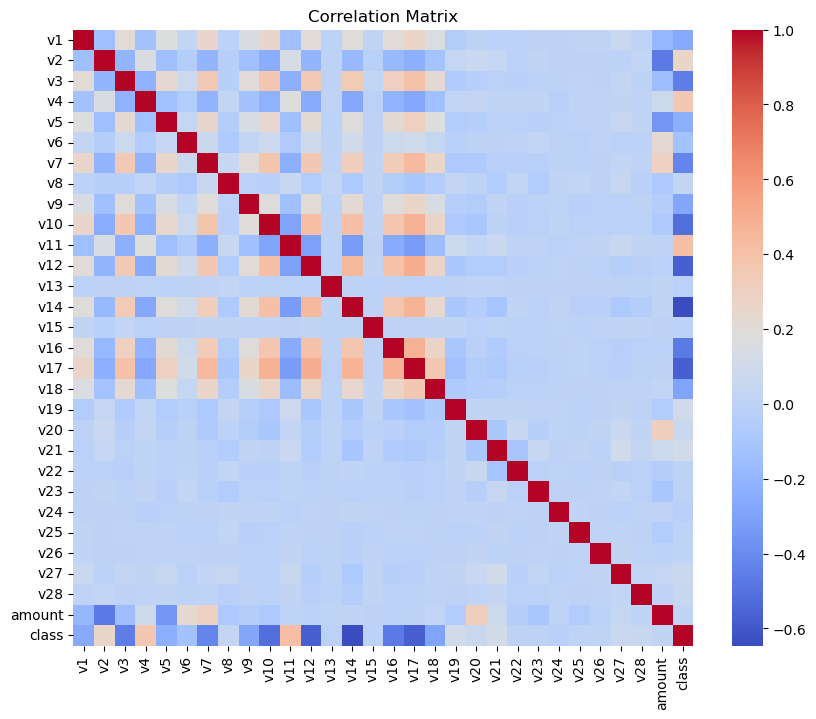

In [6]:
# Histogram
data.hist(figsize=(12,10))
plt.show()

# Safe Scatter Plot
if time_col and amount_col:
    plt.scatter(data[time_col], data[amount_col], alpha=0.3)
    plt.title("Time vs Amount")
    plt.xlabel(time_col)
    plt.ylabel(amount_col)
    plt.show()
else:
    print("⚠️ Skipping scatter plot (columns not found)")

# Correlation Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(data.corr(), cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [7]:
if target_col is None:
    raise Exception("❌ No target column found (class/target missing)")


In [8]:
X = data.drop(target_col, axis=1)
y = data[target_col]

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [10]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [11]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [12]:
y_pred = model.predict(X_test)


🎯 Accuracy: 0.9965429822539755

📊 Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      4268
           1       0.90      0.89      0.89        71

    accuracy                           1.00      4339
   macro avg       0.95      0.94      0.95      4339
weighted avg       1.00      1.00      1.00      4339



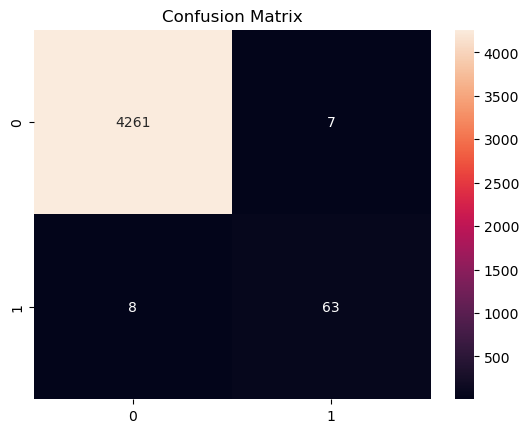

In [13]:
print("\n🎯 Accuracy:", accuracy_score(y_test, y_pred))
print("\n📊 Classification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

In [14]:
joblib.dump(model, "fraud_model.joblib")

with open("fraud_model.pkl", "wb") as f:
    pickle.dump(model, f)

print("\n✅ Model saved successfully!")


✅ Model saved successfully!


In [15]:
sample = X_test[0].reshape(1, -1)
prediction = model.predict(sample)

if prediction[0] == 1:
    print("⚠️ Fraud Transaction")
else:
    print("✅ Normal Transaction")

✅ Normal Transaction
